# SampleRateTap vs. other sample rate converters — measured

Datasheets and library docs quote quality numbers under different
definitions, signals, and bandwidths. This notebook removes that problem
for the software contenders: **one measurement implementation, applied
identically to every subject**, following the AES17 conventions hardware
vendors use:

- **THD+N**: 997 Hz at **−1 dBFS**, fundamental removed (exact-fit
  subtraction plus a ±20 Hz notch), residual integrated over
  **20 Hz–20 kHz**, unweighted, expressed in dB relative to the fundamental.
- **Dynamic range (AES17)**: the same measurement with a **−60 dBFS**
  input and **A-weighting**; DR = |THD+N| + 60 dB.

Subjects, all converting the same +200 ppm clock-offset stream
(48 009.6 Hz capture clock → 48 000 Hz playback clock):

| Subject | What it is | Clock knowledge |
|---|---|---|
| SampleRateTap (balanced) | full ASRC, float path | **must discover the ratio itself** (servo) |
| libsamplerate `sinc_best` | resampler library | given the exact ratio (oracle) |
| soxr `VHQ` | resampler library | given the exact ratio (oracle) |
| r8brain-free-src `CDSPResampler24` | resampler library | given the exact ratio (oracle) |
| SpeexDSP quality 10, float build | resampler library | given the exact ratio (oracle) |
| SpeexDSP quality 10, fixed-point build (Q15 I/O) | resampler library | given the exact ratio (oracle) |
| SampleRateTap (balanced, Q15) | full ASRC, Q15 path | **must discover the ratio itself** (servo) |
| naive FIFO | drop a sample when full | n/a |

Note the asymmetry is *against* SampleRateTap: the resampler libraries are
handed the true ratio; the ASRC has to recover it from FIFO occupancy and
still gets measured on the result. Hardware numbers can't be reproduced in
software at all (they're measured on silicon through an analog test loop),
so chips appear in the final table with **datasheet** values, clearly
labeled.


In [1]:
import ctypes, pathlib, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
import figure_digest  # prints a data digest per figure (A/B gates)
figure_digest.install()
import samplerate, soxr

FS = 48000.0
EPS = 200e-6
FS_IN = FS * (1 + EPS)
REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
TOOLS_DIR = REPO / "build"

def _find_dso(stem):
    for name in (f"lib{stem}.so", f"lib{stem}.dylib", f"{stem}.dll"):
        hits = sorted(TOOLS_DIR.rglob(name))
        if hits:
            return hits[0]
    return None

def _run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout); print(r.stderr, file=sys.stderr)
        raise RuntimeError("command failed: " + " ".join(cmd))

# tap_sr_async_capi is our C ABI; tap_sr_async_r8b_shim is a two-function C shim over the
# pinned r8brain-free-src headers (tools/compare_shim/, cmake/r8brain.cmake),
# which has no maintained Python binding.
# Always (re)build: an incremental build is quick, and loading a library
# left over from an older checkout would silently measure old code.
_run(["cmake", "-B", str(REPO / "build"), "-S", str(REPO),
      "-DCMAKE_BUILD_TYPE=Release", "-DTAP_SR_BUILD_CAPI=ON",
      "-DTAP_SR_BUILD_COMPARE_SHIM=ON"])
_run(["cmake", "--build", str(REPO / "build"), "--target", "tap_sr_async_capi",
      "tap_sr_async_r8b_shim", "tap_sr_async_speex_shim", "--config", "Release", "-j"])
DSO, R8B_DSO = _find_dso("tap_sr_async_capi"), _find_dso("tap_sr_async_r8b_shim")
SPEEX_DSO = _find_dso("tap_sr_async_speex_shim")
assert DSO is not None and R8B_DSO is not None and SPEEX_DSO is not None

_lib = ctypes.CDLL(str(DSO))
_lib.tap_sr_async_create.restype = ctypes.c_void_p
_lib.tap_sr_async_create.argtypes = [ctypes.c_double, ctypes.c_size_t, ctypes.c_int, ctypes.c_uint]
_lib.tap_sr_async_destroy.argtypes = [ctypes.c_void_p]
_FLOATP = ctypes.POINTER(ctypes.c_float)
_lib.tap_sr_async_push.argtypes = [ctypes.c_void_p, _FLOATP, ctypes.c_size_t]
_lib.tap_sr_async_push.restype = ctypes.c_size_t
_lib.tap_sr_async_pull.argtypes = [ctypes.c_void_p, _FLOATP, ctypes.c_size_t]
_lib.tap_sr_async_pull.restype = ctypes.c_size_t
_lib.tap_sr_async_status.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double)]
# The Q15 path, through the format-stated create and the _q15 push/pull.
_lib.tap_sr_async_create_format.restype = ctypes.c_void_p
_lib.tap_sr_async_create_format.argtypes = [ctypes.c_double, ctypes.c_size_t, ctypes.c_int,
                                            ctypes.c_int, ctypes.c_uint]
_I16P = ctypes.POINTER(ctypes.c_int16)
_lib.tap_sr_async_push_q15.argtypes = [ctypes.c_void_p, _I16P, ctypes.c_size_t]
_lib.tap_sr_async_push_q15.restype = ctypes.c_size_t
_lib.tap_sr_async_pull_q15.argtypes = [ctypes.c_void_p, _I16P, ctypes.c_size_t]
_lib.tap_sr_async_pull_q15.restype = ctypes.c_size_t

class Asrc:
    def __init__(self):
        self._h = _lib.tap_sr_async_create(FS, 0, 1, 1)  # balanced profile, defaults, mono
        assert self._h
    def push(self, x):
        return _lib.tap_sr_async_push(self._h, np.ascontiguousarray(x, np.float32)
                             .ctypes.data_as(_FLOATP), len(x))
    def pull(self, out):
        return _lib.tap_sr_async_pull(self._h, out.ctypes.data_as(_FLOATP), len(out))

    def underruns(self):
        s = (ctypes.c_double * 6)()
        _lib.tap_sr_async_status(self._h, s)
        return int(s[3])
    def __del__(self):
        if getattr(self, "_h", None):
            _lib.tap_sr_async_destroy(self._h)

class AsrcQ15(Asrc):
    """The Q15 datapath: float in, rounded and saturated to int16 at the push,
    int16 out scaled by 1/32768 at the pull -- a Q15 caller's interface."""
    def __init__(self):
        self._h = _lib.tap_sr_async_create_format(FS, 0, 1, 1, 1)  # balanced, Q15, mono
        assert self._h
    def push(self, x):
        q = np.clip(np.round(np.asarray(x, np.float64) * 32767.0), -32768, 32767).astype(np.int16)
        return _lib.tap_sr_async_push_q15(self._h, np.ascontiguousarray(q).ctypes.data_as(_I16P), len(q))
    def pull(self, out):
        q = np.zeros(len(out), dtype=np.int16)
        n = _lib.tap_sr_async_pull_q15(self._h, q.ctypes.data_as(_I16P), len(q))
        out[:] = q.astype(np.float32) / 32768.0
        return n

_r8b = ctypes.CDLL(str(R8B_DSO))
_r8b.tap_sr_async_r8b_oneshot.restype = ctypes.c_int
_r8b.tap_sr_async_r8b_oneshot.argtypes = [_FLOATP, ctypes.c_int, ctypes.c_double,
                                 ctypes.c_double, ctypes.c_double,
                                 ctypes.c_double, ctypes.c_int, _FLOATP,
                                 ctypes.c_int]
_r8b.tap_sr_async_r8b_latency_frames.restype = ctypes.c_int
_r8b.tap_sr_async_r8b_latency_frames.argtypes = [ctypes.c_double] * 4 + [ctypes.c_int]

def r8b_resample(x, fs_in, fs_out, trans_band=2.0, atten=180.15,
                 min_phase=False):
    """Whole-buffer r8brain conversion (its oneshot(): delay removed, tail
    flushed). Defaults are CDSPResampler24, the preset for 24-bit/float."""
    x = np.ascontiguousarray(x, np.float32)
    y = np.zeros(int(round(len(x) * fs_out / fs_in)), np.float32)
    rc = _r8b.tap_sr_async_r8b_oneshot(x.ctypes.data_as(_FLOATP), len(x), fs_in,
                              fs_out, trans_band, atten, int(min_phase),
                              y.ctypes.data_as(_FLOATP), len(y))
    assert rc == 0
    return y

def r8b_latency_frames(fs_in, fs_out, trans_band, atten, min_phase=False):
    """Input frames r8brain consumes before its first streaming output."""
    return _r8b.tap_sr_async_r8b_latency_frames(fs_in, fs_out, trans_band, atten,
                                       int(min_phase))

_speex = ctypes.CDLL(str(SPEEX_DSO))
_speex.tap_sr_async_speex_oneshot.restype = ctypes.c_int
_speex.tap_sr_async_speex_oneshot.argtypes = [_FLOATP, ctypes.c_int, ctypes.c_double,
                                              ctypes.c_double, ctypes.c_int, ctypes.c_int,
                                              _FLOATP, ctypes.c_int]
_speex.tap_sr_async_speex_latency_frames.restype = ctypes.c_int
_speex.tap_sr_async_speex_latency_frames.argtypes = [ctypes.c_double, ctypes.c_double,
                                                     ctypes.c_int, ctypes.c_int]

def speex_resample(x, fs_in, fs_out, quality=10, fixed_point=False):
    """Whole-buffer SpeexDSP conversion (its own latency skipped, tail flushed),
    through its FLOATING_POINT build, or its FIXED_POINT build on Q15 samples."""
    x = np.ascontiguousarray(x, np.float32)
    y = np.zeros(int(round(len(x) * fs_out / fs_in)), np.float32)
    rc = _speex.tap_sr_async_speex_oneshot(x.ctypes.data_as(_FLOATP), len(x), fs_in,
                                           fs_out, quality, int(fixed_point),
                                           y.ctypes.data_as(_FLOATP), len(y))
    assert rc == 0
    return y

def speex_latency_frames(fs_in, fs_out, quality, fixed_point=False):
    """Input frames SpeexDSP holds before its first output (get_input_latency)."""
    return _speex.tap_sr_async_speex_latency_frames(fs_in, fs_out, quality, int(fixed_point))

print(f"loaded {DSO.name}, {R8B_DSO.name}, {SPEEX_DSO.name}; libsamplerate via samplerate "
      f"{getattr(samplerate, '__version__', '?')}, soxr {soxr.__version__}")

loaded libtap_sr_async_capi.so, libtap_sr_async_r8b_shim.so, libtap_sr_async_speex_shim.so; libsamplerate via samplerate 0.2.4, soxr 1.1.0


## The measurement, and its calibration

Frequency is refined by the phase-slope method (per-window phase of an LS
fit, regressed against time — precision far beyond FFT bins, which a
130 dB measurement needs). The fundamental is then removed by a single
global least-squares fit at the refined frequency, residual bins within
±20 Hz of the fundamental are nulled (a far *narrower* notch than AES17
permits hardware testers — conservative against all subjects), and the
remainder is integrated over 20 Hz–20 kHz, optionally A-weighted.

The instrument is validated on synthetic signals with known answers before
it measures anything.


In [2]:
def a_weight(f):
    f2 = np.square(f)
    num = (12194.0**2) * f2 * f2
    den = ((f2 + 20.6**2) * np.sqrt((f2 + 107.7**2) * (f2 + 737.9**2))
           * (f2 + 12194.0**2))
    ra = np.divide(num, den, out=np.zeros_like(f2), where=den > 0)
    ref = (12194.0**2 * 1000.0**4) / ((1000.0**2 + 20.6**2)
          * np.sqrt((1000.0**2 + 107.7**2) * (1000.0**2 + 737.9**2))
          * (1000.0**2 + 12194.0**2))
    return ra / ref

def refine_freq(x, f0, fs=FS, win=8192, iters=3):
    n = (len(x) // win) * win
    tt = np.arange(n)
    for _ in range(iters):
        ph = []
        for k in range(n // win):
            sl = slice(k * win, (k + 1) * win)
            A = np.column_stack([np.sin(2 * np.pi * f0 / fs * tt[sl]),
                                 np.cos(2 * np.pi * f0 / fs * tt[sl])])
            c, *_ = np.linalg.lstsq(A, x[sl].astype(np.float64), rcond=None)
            ph.append(np.arctan2(c[1], c[0]))
        ph = np.unwrap(ph)
        tk = (np.arange(len(ph)) + 0.5) * win / fs
        slope = np.polyfit(tk, ph, 1)[0]      # rad/s of phase drift
        f0 += slope / (2 * np.pi)
    return f0

def thdn_db(x, f0_nominal, fs=FS, weighted=False, notch_hz=20.0,
            band=(20.0, 20000.0)):
    """AES17-style THD+N in dB relative to the fundamental (negative)."""
    x = x.astype(np.float64)
    f0 = refine_freq(x, f0_nominal, fs)
    tt = np.arange(len(x))
    A = np.column_stack([np.sin(2 * np.pi * f0 / fs * tt),
                         np.cos(2 * np.pi * f0 / fs * tt)])
    c, *_ = np.linalg.lstsq(A, x, rcond=None)
    fund_rms = np.hypot(c[0], c[1]) / np.sqrt(2)
    resid = x - A @ c
    R = np.fft.rfft(resid)
    f = np.fft.rfftfreq(len(resid), 1 / fs)
    mask = (f >= band[0]) & (f <= band[1]) & (np.abs(f - f0) > notch_hz)
    w = a_weight(f) if weighted else np.ones_like(f)
    resid_rms = np.sqrt(np.sum(np.abs(R[mask] * w[mask])**2)
                        * 2 / len(resid)**2)
    return 20 * np.log10(resid_rms / fund_rms), f0

# --- calibration ----------------------------------------------------------
rng = np.random.default_rng(11)
n = int(8 * FS)
tone = 10 ** (-1 / 20) * np.sin(2 * np.pi * 997.003 / FS * np.arange(n))
for noise_db in (-100.0, -130.0):
    sig = (tone + 10 ** (noise_db / 20) * rng.standard_normal(n)).astype(np.float32)
    got, f0 = thdn_db(sig, 997.0)
    # Exact expectation: noise rms 10^(dB/20) against the -1 dBFS
    # fundamental's rms, reduced by the in-band fraction of white noise
    # captured by the 20 Hz-20 kHz window.
    inband = (20000.0 - 20.0) / (FS / 2)
    expect = (noise_db - 20 * np.log10(10 ** (-1 / 20) / np.sqrt(2))
              + 10 * np.log10(inband))
    print(f"injected {noise_db:6.1f} dBFS noise -> measured THD+N {got:7.2f} dB "
          f"(expect {expect:7.2f}), refined f0 {f0:.4f} Hz")
    assert abs(got - expect) < 0.5
print("instrument calibrated")

injected -100.0 dBFS noise -> measured THD+N  -96.80 dB (expect  -96.79), refined f0 997.0030 Hz


injected -130.0 dBFS noise -> measured THD+N -126.80 dB (expect -126.79), refined f0 997.0030 Hz
instrument calibrated


## Subjects under identical conditions

Input stream: 997 Hz sampled by the 48 009.6 Hz capture clock. Output:
48 000 Hz. The resampler libraries get the exact ratio; SampleRateTap gets
nothing and must lock first (we analyze its output well after the servo's
Quiet stage engages).


In [3]:
def make_input(seconds, amp_dbfs):
    n = int(seconds * FS_IN) + 64
    amp = 10 ** (amp_dbfs / 20)
    return (amp * np.sin(2 * np.pi * 997.0 / FS_IN * np.arange(n))
            ).astype(np.float32)

def mid_window(y, analyze_s, guard_s=1.0):
    """Trim both ends: one-shot converters flush a filter tail at the end of
    the stream, and including it poisons the measurement by ~60 dB (found
    the hard way; a control experiment at 2:1 exposed it)."""
    y = np.asarray(y, dtype=np.float32)
    end = len(y) - int(guard_s * FS)
    return y[end - int(analyze_s * FS):end]

def q24(y):
    """Round to a 24-bit interface, undithered -- what a hardware ASRC
    presents at its pins. The equalizer that makes software and silicon
    numbers directly comparable."""
    return np.round(np.asarray(y, np.float64) * 8388608.0) / 8388608.0

def via_sampleratetap(x, seconds, settle_s, q15=False):
    asrc = AsrcQ15() if q15 else Asrc()
    n_out = int(seconds * FS)
    out = np.zeros(n_out + 1, dtype=np.float32)
    buf = np.zeros(1, dtype=np.float32)
    t_in = t_out = 0.0
    i_in = i_out = 0
    while i_out < n_out:
        if t_in <= t_out:
            asrc.push(x[i_in:i_in + 1]); i_in += 1; t_in += 1 / FS_IN
        else:
            asrc.pull(buf); out[i_out] = buf[0]; i_out += 1; t_out += 1 / FS
    assert asrc.underruns() == 0
    return out[int(settle_s * FS):n_out]

def via_libsamplerate(x, analyze_s):
    return mid_window(samplerate.resample(x, FS / FS_IN, "sinc_best"), analyze_s)

def via_soxr(x, analyze_s):
    return mid_window(soxr.resample(x, FS_IN, FS, quality="VHQ"), analyze_s)

def via_r8brain(x, analyze_s):
    return mid_window(r8b_resample(x, FS_IN, FS), analyze_s)

def via_speex(x, analyze_s, fixed_point=False):
    return mid_window(speex_resample(x, FS_IN, FS, 10, fixed_point), analyze_s)

def via_naive(x, analyze_s):
    period = int(round(1 / EPS))
    keep = np.ones(len(x), dtype=bool)
    keep[period::period] = False
    return mid_window(x[keep], analyze_s)

SECONDS, SETTLE, ANALYZE = 32.0, 25.0, 6.0
x_full = make_input(SECONDS, -1.0)
subjects = {
    "SampleRateTap (servo)": via_sampleratetap(x_full, SECONDS, SETTLE),
    "libsamplerate sinc_best (oracle ratio)": via_libsamplerate(x_full, ANALYZE),
    "soxr VHQ (oracle ratio)": via_soxr(x_full, ANALYZE),
    "r8brain 24-bit (oracle ratio)": via_r8brain(x_full, ANALYZE),
    "SpeexDSP q10 float (oracle ratio)": via_speex(x_full, ANALYZE),
    "SpeexDSP q10 fixed-point (oracle ratio)": via_speex(x_full, ANALYZE, True),
    "SampleRateTap Q15 (servo)": via_sampleratetap(x_full, SECONDS, SETTLE, True),
    "naive FIFO drops": via_naive(x_full, ANALYZE),
}
thdn, thdn24 = {}, {}
for name, y in subjects.items():
    thdn[name], _ = thdn_db(y, 997.0)
    thdn24[name], _ = thdn_db(q24(y), 997.0)
    print(f"{name:42s} THD+N {thdn24[name]:8.2f} dB (24-bit IO)   "
          f"{thdn[name]:8.2f} dB (float IO)")


SampleRateTap (servo)                      THD+N  -133.91 dB (24-bit IO)    -134.28 dB (float IO)
libsamplerate sinc_best (oracle ratio)     THD+N  -143.50 dB (24-bit IO)    -149.35 dB (float IO)


soxr VHQ (oracle ratio)                    THD+N  -143.82 dB (24-bit IO)    -150.75 dB (float IO)
r8brain 24-bit (oracle ratio)              THD+N  -143.85 dB (24-bit IO)    -150.75 dB (float IO)


SpeexDSP q10 float (oracle ratio)          THD+N  -133.74 dB (24-bit IO)    -134.09 dB (float IO)
SpeexDSP q10 fixed-point (oracle ratio)    THD+N   -80.23 dB (24-bit IO)     -80.23 dB (float IO)


SampleRateTap Q15 (servo)                  THD+N   -76.64 dB (24-bit IO)     -76.64 dB (float IO)
naive FIFO drops                           THD+N   -34.66 dB (24-bit IO)     -34.66 dB (float IO)


## Dynamic range (AES17): −60 dBFS input, A-weighted

Reported at the **24-bit interface**: floating-point pipelines have no fixed
noise floor (absolute noise scales down with the signal), so their "native"
DR mostly measures the arithmetic format, not the converter. Quantizing
every subject's output to 24 bits puts software on the same footing as the
silicon it is compared with. Native-float values shown for completeness.


In [4]:
x_quiet = make_input(SECONDS, -60.0)
subjects_dr = {
    "SampleRateTap (servo)": via_sampleratetap(x_quiet, SECONDS, SETTLE),
    "libsamplerate sinc_best (oracle ratio)": via_libsamplerate(x_quiet, ANALYZE),
    "soxr VHQ (oracle ratio)": via_soxr(x_quiet, ANALYZE),
    "r8brain 24-bit (oracle ratio)": via_r8brain(x_quiet, ANALYZE),
    "SpeexDSP q10 float (oracle ratio)": via_speex(x_quiet, ANALYZE),
    "SpeexDSP q10 fixed-point (oracle ratio)": via_speex(x_quiet, ANALYZE, True),
    "SampleRateTap Q15 (servo)": via_sampleratetap(x_quiet, SECONDS, SETTLE, True),
    "naive FIFO drops": via_naive(x_quiet, ANALYZE),
}
dr, dr24 = {}, {}
for name, y in subjects_dr.items():
    t, _ = thdn_db(y, 997.0, weighted=True)
    t24, _ = thdn_db(q24(y), 997.0, weighted=True)
    dr[name], dr24[name] = -t + 60.0, -t24 + 60.0
    print(f"{name:42s} DR {dr24[name]:7.1f} dB (24-bit IO)   "
          f"{dr[name]:7.1f} dB (float IO)")


SampleRateTap (servo)                      DR   149.1 dB (24-bit IO)     194.3 dB (float IO)
libsamplerate sinc_best (oracle ratio)     DR   149.1 dB (24-bit IO)     210.2 dB (float IO)


soxr VHQ (oracle ratio)                    DR   149.1 dB (24-bit IO)     211.8 dB (float IO)


r8brain 24-bit (oracle ratio)              DR   149.1 dB (24-bit IO)     211.7 dB (float IO)
SpeexDSP q10 float (oracle ratio)          DR   149.1 dB (24-bit IO)     194.0 dB (float IO)


SpeexDSP q10 fixed-point (oracle ratio)    DR    97.4 dB (24-bit IO)      97.4 dB (float IO)


SampleRateTap Q15 (servo)                  DR    97.3 dB (24-bit IO)      97.3 dB (float IO)
naive FIFO drops                           DR    94.7 dB (24-bit IO)      94.7 dB (float IO)


## Results


[ figure ] digest 63a2260b28922f8d (19 arrays)


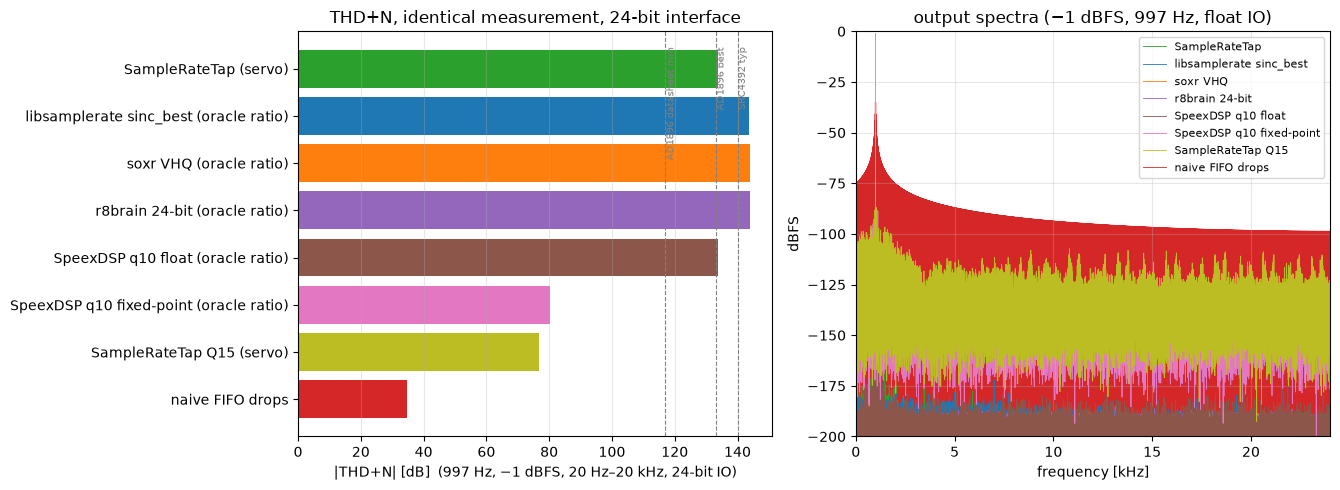

subject                                     THD+N 24b  THD+N fl  DR 24b   DR fl
SampleRateTap (servo)                         -133.91   -134.28   149.1   194.3
libsamplerate sinc_best (oracle ratio)        -143.50   -149.35   149.1   210.2
soxr VHQ (oracle ratio)                       -143.82   -150.75   149.1   211.8
r8brain 24-bit (oracle ratio)                 -143.85   -150.75   149.1   211.7
SpeexDSP q10 float (oracle ratio)             -133.74   -134.09   149.1   194.0
SpeexDSP q10 fixed-point (oracle ratio)        -80.23    -80.23    97.4    97.4
SampleRateTap Q15 (servo)                      -76.64    -76.64    97.3    97.3
naive FIFO drops                               -34.66    -34.66    94.7    94.7


In [5]:
names = list(subjects.keys())
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5))
colors = ["tab:green", "tab:blue", "tab:orange", "tab:purple", "tab:brown",
          "tab:pink", "tab:olive", "tab:red"]
ax[0].barh(names[::-1], [-thdn24[n] for n in names][::-1], color=colors[::-1])
ax[0].set(xlabel="|THD+N| [dB]  (997 Hz, −1 dBFS, 20 Hz–20 kHz, 24-bit IO)",
          title="THD+N, identical measurement, 24-bit interface")
for hw, v in (("AD1896 datasheet min", 117), ("AD1896 best", 133),
              ("SRC4392 typ", 140)):
    ax[0].axvline(v, ls="--", lw=0.8, color="gray")
    ax[0].text(v, len(names) - 0.55, " " + hw, rotation=90, fontsize=7, va="top", color="gray")
ax[0].grid(alpha=0.3, axis="x")

for k, (name, y) in enumerate(subjects.items()):
    w = np.kaiser(len(y), 24.0)
    Y = np.abs(np.fft.rfft(y.astype(np.float64) * w)) / (np.sum(w) / 2)
    f = np.fft.rfftfreq(len(y), 1 / FS)
    # Same colors as the bars; the naive FIFO's splatter goes underneath.
    ax[1].plot(f / 1e3, 20 * np.log10(np.maximum(Y, 1e-12)), lw=0.6,
               color=colors[k], zorder=0 if "naive" in name else 2,
               label=name.split(" (")[0])
ax[1].set(xlabel="frequency [kHz]", ylabel="dBFS", xlim=(0, 24), ylim=(-200, 0),
          title="output spectra (−1 dBFS, 997 Hz, float IO)")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'subject':42s} {'THD+N 24b':>10s} {'THD+N fl':>9s} {'DR 24b':>7s} {'DR fl':>7s}")
for n_ in names:
    print(f"{n_:42s} {thdn24[n_]:10.2f} {thdn[n_]:9.2f} {dr24[n_]:7.1f} {dr[n_]:7.1f}")

first = names[0]
assert thdn[first] < -130 and dr24[first] > 130
# r8brain's 24-bit preset sits at the 24-bit interface ceiling, like the
# other oracle-fed libraries (docs/COMPARISON.md).
r8b_name = "r8brain 24-bit (oracle ratio)"
assert thdn24[r8b_name] < -143.0 and dr24[r8b_name] > 149.0


## Latency vs. passband: where r8brain's delay comes from

r8brain is a streaming engine too, so its latency is a fair question.
Its streaming latency is the number of input frames it consumes before
producing the first output (it hides its filter delay by withholding
output). That number is set by the **transition band** knob, and a
wide transition band pulls the passband edge down. The honest comparison
fixes the passband SampleRateTap `balanced` delivers (flat to 20 kHz) and
asks what r8brain's delay is there. Both axes below are measured on the
pinned engine through the shim: latency from `getInLenBeforeOutPos(0)`,
passband gain from a 20 kHz sine fit through `oneshot()`, at 120 dB
stopband (the `balanced` tier), same +200 ppm ratio.


trans band   phase        latency  gain @ 20 kHz
      2.0%  linear   789 fr 16.44 ms       +0.0000 dB
      2.0%     min   554 fr 11.54 ms       +0.0000 dB
      5.0%  linear   420 fr  8.75 ms       +0.0000 dB
      5.0%     min   328 fr  6.83 ms       +0.0000 dB
      8.0%  linear   200 fr  4.17 ms       -0.0000 dB
      8.0%     min   143 fr  2.98 ms       -0.0004 dB
     10.0%  linear   212 fr  4.42 ms       -0.0004 dB
     10.0%     min   167 fr  3.48 ms       -0.0007 dB
     12.0%  linear   220 fr  4.58 ms       -0.1109 dB
     12.0%     min   183 fr  3.81 ms       -0.1110 dB
     15.0%  linear   100 fr  2.08 ms       -1.4886 dB
     15.0%     min    71 fr  1.48 ms       -1.4912 dB
     20.0%  linear   108 fr  2.25 ms       -6.9984 dB
     20.0%     min    87 fr  1.81 ms       -6.9994 dB
     30.0%  linear   116 fr  2.42 ms      -20.1669 dB
     30.0%     min   103 fr  2.15 ms      -20.1696 dB
     45.0%  linear    57 fr  1.19 ms      -35.4380 dB
     45.0%     min    50 fr  1.04

[ figure ] digest 1d543ecb34ac77c0 (4 arrays)


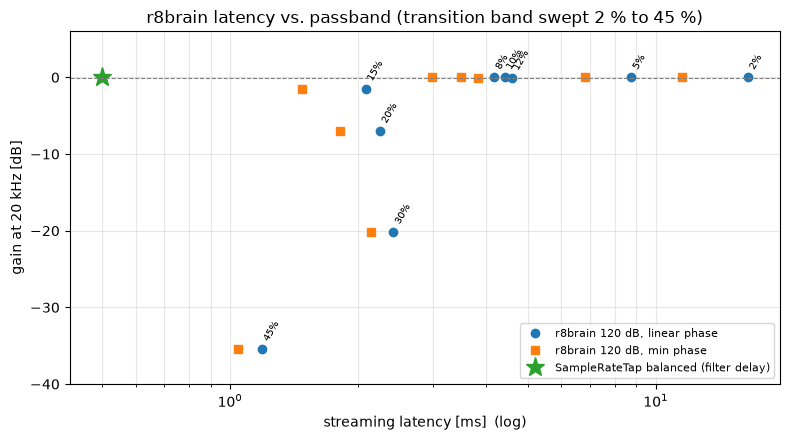

lowest-latency r8brain setting flat to 20 kHz (within 0.01 dB): 8% transition band, min phase, 143 frames = 2.98 ms


In [6]:
def gain_db(y, f, fs, skip=0.25):
    """Least-squares amplitude of a known-frequency sine, in dB re 0.5."""
    a, b = int(len(y) * skip), int(len(y) * (1 - skip))
    tt = np.arange(a, b)
    A = np.column_stack([np.sin(2 * np.pi * f / fs * tt),
                         np.cos(2 * np.pi * f / fs * tt)])
    c, *_ = np.linalg.lstsq(A, y[a:b].astype(np.float64), rcond=None)
    return 20 * np.log10(np.hypot(*c) / 0.5)

probe = (0.5 * np.sin(2 * np.pi * 20000.0 / FS_IN * np.arange(1 << 16))
         ).astype(np.float32)
TAP_SR_ASYNC_GD = 24   # balanced filter group delay, input frames (README "Latency")
rows = []
for tb in (2.0, 5.0, 8.0, 10.0, 12.0, 15.0, 20.0, 30.0, 45.0):
    for mp in (False, True):
        lat = r8b_latency_frames(FS_IN, FS, tb, 120.0, mp)
        g20 = gain_db(r8b_resample(probe, FS_IN, FS, tb, 120.0, mp),
                      20000.0, FS)
        rows.append((tb, mp, lat, g20))

print(f"{'trans band':>10s} {'phase':>7s} {'latency':>14s} {'gain @ 20 kHz':>14s}")
for tb, mp, lat, g20 in rows:
    print(f"{tb:9.1f}% {'min' if mp else 'linear':>7s} {lat:5d} fr {lat / FS * 1e3:5.2f} ms"
          f" {g20:+13.4f} dB")

fig, ax = plt.subplots(figsize=(8, 4.5))
# Markers, not lines: latency is not monotonic in the transition band.
for mp, mk in ((False, "o"), (True, "s")):
    pts = [(lat / FS * 1e3, g20) for tb, m, lat, g20 in rows if m == mp]
    ax.plot(*zip(*pts), mk, label=f"r8brain 120 dB, {'min' if mp else 'linear'} phase")
for tb, mp, lat, g20 in rows:
    if not mp:  # rotated so the 8/10/12 % cluster stays legible
        ax.annotate(f"{tb:g}%", (lat / FS * 1e3, g20), textcoords="offset points",
                    xytext=(0, 6), fontsize=7, rotation=60)
ax.plot([TAP_SR_ASYNC_GD / FS * 1e3], [0.0], "*", ms=14, color="tab:green",
        label="SampleRateTap balanced (filter delay)")
ax.set(xscale="log", xlabel="streaming latency [ms]  (log)",
       ylabel="gain at 20 kHz [dB]", ylim=(-40, 6),
       title="r8brain latency vs. passband (transition band swept 2 % to 45 %)")
ax.axhline(-0.1, ls="--", lw=0.8, color="gray")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

flat = [(tb, mp, lat) for tb, mp, lat, g20 in rows if g20 > -0.01]
best = min(flat, key=lambda r: r[2])
print(f"lowest-latency r8brain setting flat to 20 kHz (within 0.01 dB): "
      f"{best[0]:.0f}% transition band, {'min' if best[1] else 'linear'} phase, "
      f"{best[2]} frames = {best[2] / FS * 1e3:.2f} ms")
# Pins for docs/COMPARISON.md and bench/compare's passband-matched row.
assert all(lat > 4 * TAP_SR_ASYNC_GD for tb, mp, lat in flat)
assert [r for r in rows if r[0] == 10.0 and not r[1]][0][3] > -0.01


## SpeexDSP: the same two questions

SpeexDSP's quality knob (0–10) sets its filter length, oversampling and
cutoff together; its own table calls quality 10 "~100 dB stop", below
both tiers the rest of this document pairs. It is here for one reason:
it is the only library in the set with a **fixed-point build**, so it is
the only competitor that can run on an FP64-less core on the terms our
Q15 row runs. The sweep below measures latency (`get_input_latency()`)
and the 20 kHz passband gain per quality, through both builds. Its
filters are short (at quality 10 the sinc spans eight input samples), so
no quality is flat to 20 kHz: the gain there settles at about −0.42 dB
from quality 4 up. The matched row beside quality 10 in the cost tables
is therefore quality 4, the lowest at that passband knee, at a quarter
of quality 10's latency. The quality rows above are its quality 10, both
builds, at the ceilings its arithmetic allows.


quality  build        latency  gain @ 20 kHz
      0  float     4 fr  0.08 ms       -6.5655 dB
      0  fixed     4 fr  0.08 ms       -6.5662 dB
      1  float     8 fr  0.17 ms       -5.3794 dB
      1  fixed     8 fr  0.17 ms       -5.3804 dB
      2  float    16 fr  0.33 ms       -1.9503 dB
      2  fixed    16 fr  0.33 ms       -1.9531 dB
      3  float    24 fr  0.50 ms       -0.8208 dB
      3  fixed    24 fr  0.50 ms       -0.8220 dB
      4  float    32 fr  0.67 ms       -0.4207 dB
      4  fixed    32 fr  0.67 ms       -0.4221 dB
      5  float    40 fr  0.83 ms       -0.4199 dB
      5  fixed    40 fr  0.83 ms       -0.4208 dB
      6  float    48 fr  1.00 ms       -0.4200 dB
      6  fixed    48 fr  1.00 ms       -0.4215 dB
      7  float    64 fr  1.33 ms       -0.4199 dB
      7  fixed    64 fr  1.33 ms       -0.4209 dB
      8  float    80 fr  1.67 ms       -0.4199 dB
      8  fixed    80 fr  1.67 ms       -0.4207 dB
      9  float    96 fr  2.00 ms       -0.4198 dB
     

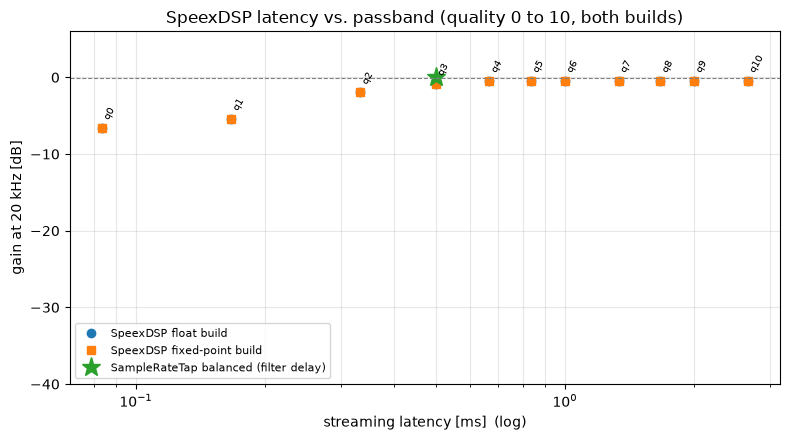

SpeexDSP gain at 20 kHz at its best quality: -0.420 dB (never flat); lowest quality at that knee: q4, 32 frames = 0.67 ms


In [7]:
rows_sp = []
for q in range(11):
    for fx in (False, True):
        lat = speex_latency_frames(FS_IN, FS, q, fx)
        g20 = gain_db(speex_resample(probe, FS_IN, FS, q, fx), 20000.0, FS)
        rows_sp.append((q, fx, lat, g20))

print(f"{'quality':>7s} {'build':>6s} {'latency':>14s} {'gain @ 20 kHz':>14s}")
for q, fx, lat, g20 in rows_sp:
    print(f"{q:7d} {'fixed' if fx else 'float':>6s} {lat:5d} fr {lat / FS * 1e3:5.2f} ms"
          f" {g20:+13.4f} dB")

fig, ax = plt.subplots(figsize=(8, 4.5))
for fx, mk in ((False, "o"), (True, "s")):
    pts = [(lat / FS * 1e3, g20) for q, f, lat, g20 in rows_sp if f == fx]
    ax.plot(*zip(*pts), mk, label=f"SpeexDSP {'fixed-point' if fx else 'float'} build")
for q, fx, lat, g20 in rows_sp:
    if not fx:
        ax.annotate(f"q{q}", (lat / FS * 1e3, g20), textcoords="offset points",
                    xytext=(0, 6), fontsize=7, rotation=60)
ax.plot([TAP_SR_ASYNC_GD / FS * 1e3], [0.0], "*", ms=14, color="tab:green",
        label="SampleRateTap balanced (filter delay)")
ax.set(xscale="log", xlabel="streaming latency [ms]  (log)",
       ylabel="gain at 20 kHz [dB]", ylim=(-40, 6),
       title="SpeexDSP latency vs. passband (quality 0 to 10, both builds)")
ax.axhline(-0.1, ls="--", lw=0.8, color="gray")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# No quality is flat to 20 kHz: the gain there settles at about -0.42 dB
# from quality 4 up (the filters are short -- at quality 10 the sinc spans
# eight input samples), so "flat to 20 kHz" selects nothing. The matched
# row is instead the lowest quality at that passband knee, within 0.01 dB
# of quality 10's gain, which costs a quarter of its latency.
g10 = [g20 for q, fx, lat, g20 in rows_sp if q == 10 and not fx][0]
knee = min((q, lat) for q, fx, lat, g20 in rows_sp if not fx and g20 > g10 - 0.01)
print(f"SpeexDSP gain at 20 kHz at its best quality: {g10:+.3f} dB (never flat); "
      f"lowest quality at that knee: q{knee[0]}, {knee[1]} frames = {knee[1] / FS * 1e3:.2f} ms")
# Pins for bench/compare and the icount workloads' quality-4 rows.
assert max(g20 for q, fx, lat, g20 in rows_sp) < -0.4
assert knee[0] == 4


## Reading the results

- **The oracle-fed libraries all reach the format ceilings.** libsamplerate
  `sinc_best`, soxr `VHQ` and r8brain's 24-bit preset each measure at the
  24-bit interface ceiling (~−143.5 dB THD+N, 149.1 dB DR) and at the float32
  I/O ceiling (~−150 dB). Their differences live below both floors, so this
  measurement cannot rank them: at near-unity with the exact ratio handed to
  them, all three are transparent.
- **SampleRateTap measures ~−134 dB with the servo in the loop**, about 10 dB
  above the 24-bit ceiling and at 149.1 dB DR (the same DR as the libraries,
  because A-weighted DR at −60 dBFS sits under the 24-bit floor for every
  real converter here). The residual is phase-table interpolation images
  plus servo sidebands beyond the ±20 Hz notch. The libraries were handed
  the exact ratio and ran offline over the whole file; the ASRC discovered
  the clock itself and ran causally at 1.5 ms latency. That gap is the
  measured price of the part of the problem the libraries do not solve.
- **r8brain's delay is a design choice, not a constant.** The sweep above
  shows the whole trade: at its default 2 % transition band it withholds
  789 input frames (16 ms) before the first output; relaxing the band cuts
  that to ~1 ms, but only by rolling the passband off to −35 dB at 20 kHz.
  Holding the passband SampleRateTap `balanced` delivers (flat to 20 kHz),
  its floor is 200 frames (4.2 ms) linear-phase, 143 frames (3.0 ms)
  minimum-phase, against `balanced`'s 24-frame filter delay.
- **The two fixed-point rows measure each other's floor.** SpeexDSP's
  fixed-point build at quality 10 and SampleRateTap's Q15 datapath both land
  at ~97 dB DR (the 16-bit interface's A-weighted ceiling, 97.4 and 97.3) and
  within a few dB in THD+N (−80.2 and −76.6): both are format-limited, and
  the README's 77 dB for `converter_q15` is this measurement. Speex's float
  build at quality 10 sits where `balanced` does (−134 dB, 149.1 dB DR):
  its "~100 dB" rating is a stopband figure, and at near-unity the images
  it leaves fall below the 24-bit floor, as the other libraries' do.
- libsamplerate's own "97 dB worst case" spec is for aggressive ratios;
  near-unity is its easy regime and it measures far better here. Conversely,
  near-unity is the *only* regime of the drift problem.
- The naive FIFO row is the cost of doing nothing.

Hardware caveats remain: silicon is measured through an analog test loop
with wider notches (both flatter the number); these software measurements
are pristine-digital. See `docs/COMPARISON.md` for the full landscape table,
including the computational comparison (host throughput and embedded
instruction counts) for every subject here.
